In [1]:

# Importing required libraries 
import numpy as np 
import pandas as pd 
import matplotlib as plt 
from statsmodels.tsa.seasonal import seasonal_decompose
# holt winters 
# single exponential smoothing
from statsmodels.tsa.holtwinters import SimpleExpSmoothing   
# double and triple exponential smoothing
from statsmodels.tsa.holtwinters import ExponentialSmoothing as HWES
  
# Read the AirPassengers dataset 
sea_passanger = pd.read_csv('2020-2025.csv',
                            index_col ='Tahun', 
                            parse_dates = True) 
  


C:\Users\athiy\AppData\Local\Temp\ipykernel_17832\2053332394.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sea_passanger = pd.read_csv('2020-2025.csv',


In [2]:
# Print the first five rows of the dataset 
sea_passanger
  

,Penumpang
Tahun,
2020-01-01,18821
2020-02-01,14667
2020-03-01,17103
2020-04-01,5024
2020-05-01,2267
...,...
2024-11-01,23251
2024-12-01,25349
2025-01-01,18614


In [3]:
sea_passanger.describe()

,Penumpang
count,63.000000
mean,22934.492063
std,12850.799544
min,2267.000000
25%,13731.000000
50%,19754.000000
75%,32522.000000
max,61649.000000


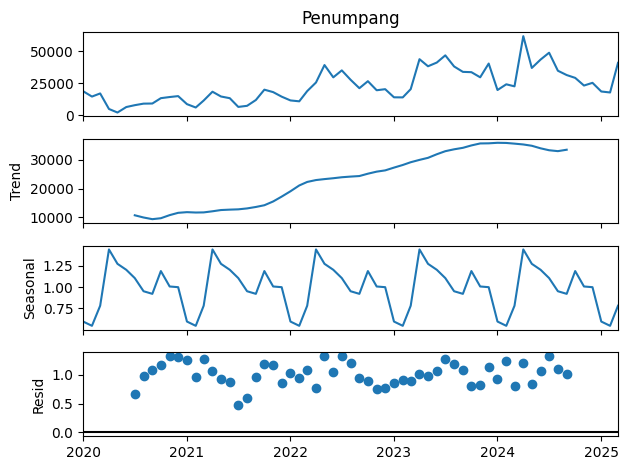

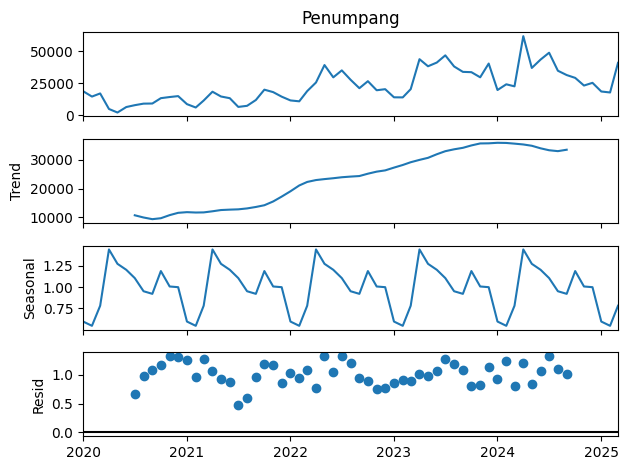

In [4]:
# ETS Decomposition 
result = seasonal_decompose(sea_passanger['Penumpang'],  
                            model ='multiplicative') 
  
# ETS plot  
result.plot() 


In [5]:
# Set the frequency of the date time index as Monthly start as indicated by the data
sea_passanger.index.freq = 'MS'
# Set the value of Alpha and define m (Time Period)
m = 12
alpha = 1/(2*m)

<Axes: title={'center': 'Holt Winters Single Exponential Smoothing'}, xlabel='Tahun'>

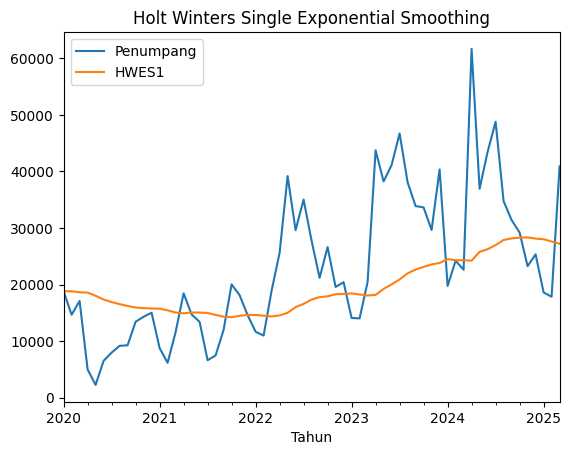

In [6]:
#Single HWES
sea_passanger['HWES1'] = SimpleExpSmoothing(sea_passanger['Penumpang']).fit(smoothing_level=alpha,optimized=False,use_brute=True).fittedvalues
sea_passanger[['Penumpang', 'HWES1']].plot(title= 'Holt Winters Single Exponential Smoothing')

C:\Users\athiy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Users\athiy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


<Axes: title={'center': 'Holt Winters Double Exponential Smoothing : Additive & Multiplicative Trend'}, xlabel='Tahun'>

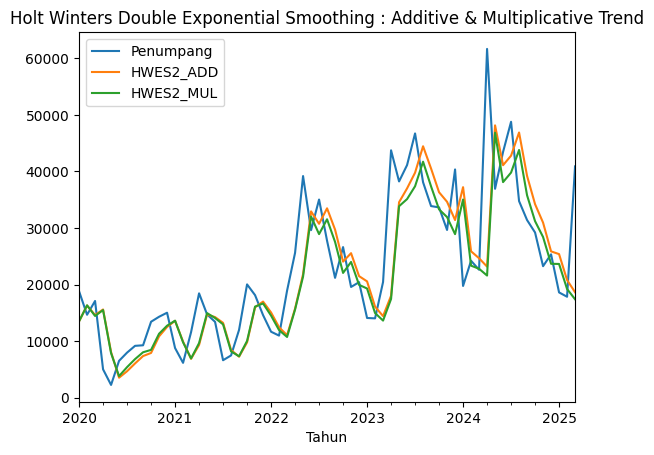

In [7]:
#Double HWES
sea_passanger['HWES2_ADD'] = HWES(sea_passanger['Penumpang'] , trend='add').fit().fittedvalues
sea_passanger['HWES2_MUL'] = HWES(sea_passanger['Penumpang'] , trend='mul').fit().fittedvalues

sea_passanger[['Penumpang', 'HWES2_ADD', 'HWES2_MUL']].plot(title= 'Holt Winters Double Exponential Smoothing : Additive & Multiplicative Trend')

C:\Users\athiy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Users\athiy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


<Axes: title={'center': 'Holt Winters Triple Exponential Smoothing : Additive & Multiplicative Trend'}, xlabel='Tahun'>

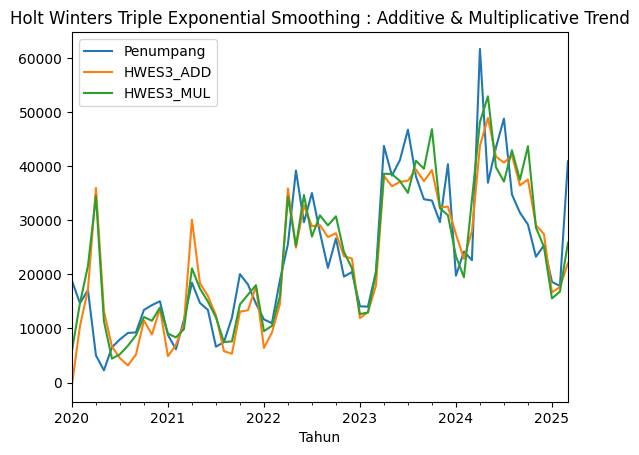

In [8]:
#Triple HWES
sea_passanger['HWES3_ADD'] = HWES(sea_passanger['Penumpang'] , trend='add', seasonal='add', seasonal_periods=12).fit().fittedvalues
sea_passanger['HWES3_MUL'] = HWES(sea_passanger['Penumpang'] , trend='mul', seasonal='mul', seasonal_periods=12).fit().fittedvalues

sea_passanger[['Penumpang', 'HWES3_ADD', 'HWES3_MUL']].plot(title= 'Holt Winters Triple Exponential Smoothing : Additive & Multiplicative Trend')

C:\Users\athiy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


<Axes: xlabel='Tahun'>

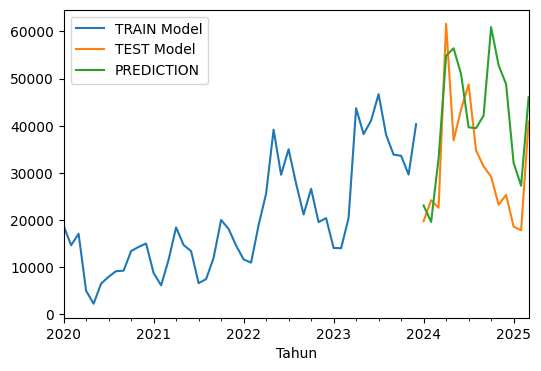

In [9]:
# Split data into train / test sets 
train = sea_passanger[:48] 
test = sea_passanger[48:] # set one year(12 months) for testing 

# model HOLT WINTERS
fitted_model = HWES(train['Penumpang'],trend='mul',seasonal='mul',seasonal_periods=12).fit()
test_predictions = fitted_model.forecast(15)
train['Penumpang'].plot(legend=True,label= 'TRAIN Model')
test['Penumpang'].plot(legend=True,label= 'TEST Model',figsize=(6,4))
test_predictions.plot(legend=True,label= 'PREDICTION')
          

<Axes: xlabel='Tahun'>

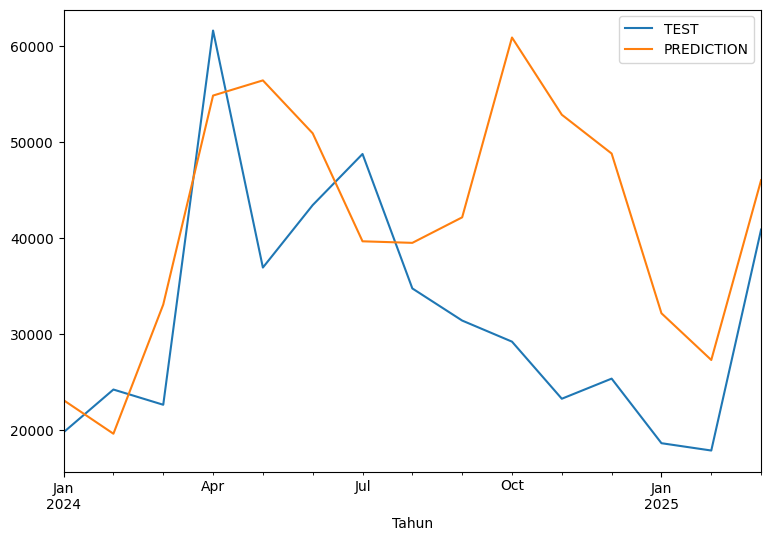

In [10]:
test['Penumpang'].plot(legend=True,label= 'TEST',figsize=(9,6))
test_predictions.plot(legend=True,label='PREDICTION')

In [11]:
test_predictions

2024-01-01    23099.812893
2024-02-01    19602.150197
2024-03-01    33070.749946
2024-04-01    54866.310370
2024-05-01    56448.771082
2024-06-01    50929.478262
2024-07-01    39668.558696
2024-08-01    39506.978261
2024-09-01    42167.940463
2024-10-01    60920.168469
2024-11-01    52867.770528
2024-12-01    48819.647004
2025-01-01    32162.647361
2025-02-01    27292.733808
2025-03-01    46045.518785
Freq: MS, dtype: float64

In [12]:
# Load specific evaluation tools 
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from statsmodels.tools.eval_measures import rmse 

# Calculate root mean squared error 
RMSE = rmse(test["Penumpang"], test_predictions) 

# Calculate mean squared error 
MSE = mean_squared_error(test["Penumpang"], test_predictions) 

# Calculate mean absolute error 
MAE = mean_absolute_error(test["Penumpang"], test_predictions) 

# R squared
R2 = r2_score(test["Penumpang"], test_predictions) 

# MAPE
MAPE = mean_absolute_percentage_error(test['Penumpang'], test_predictions)


C:\Users\athiy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\utils\validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
C:\Users\athiy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\utils\validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):
C:\Users\athiy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\utils\validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instea

In [13]:
print(f'''
RMSE   : { round(RMSE, 3) }

MSE   : { round(MSE, 3) }

MAE   : { round(MAE, 3) }

R2    : { round(R2, 3) } 

MAPE   : { round(MAPE, 3) }
MAPE % : { round(MAPE*100, 3) } %
''')



RMSE   : 15447.032

MSE   : 238610797.734

MAE   : 12650.747

R2    : -0.62 

MAPE   : 0.464
MAPE % : 46.448 %



In [14]:
print(test_predictions)


2024-01-01    23099.812893
2024-02-01    19602.150197
2024-03-01    33070.749946
2024-04-01    54866.310370
2024-05-01    56448.771082
2024-06-01    50929.478262
2024-07-01    39668.558696
2024-08-01    39506.978261
2024-09-01    42167.940463
2024-10-01    60920.168469
2024-11-01    52867.770528
2024-12-01    48819.647004
2025-01-01    32162.647361
2025-02-01    27292.733808
2025-03-01    46045.518785
Freq: MS, dtype: float64


<Axes: title={'center': 'Holt Winters Triple Exponential Smoothing : Additive & Multiplicative Trend'}, xlabel='Tahun'>

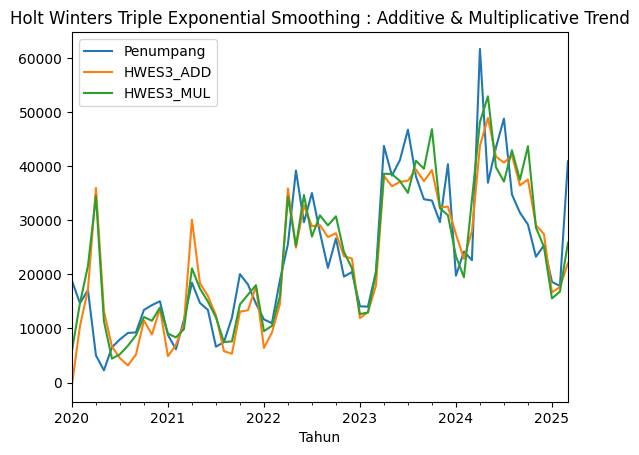

In [15]:
sea_passanger[['Penumpang', 'HWES3_ADD', 'HWES3_MUL']].plot(title= 'Holt Winters Triple Exponential Smoothing : Additive & Multiplicative Trend')



In [16]:
# Load specific evaluation tools 
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from statsmodels.tools.eval_measures import rmse 

Mape3_add = mean_absolute_percentage_error(sea_passanger['Penumpang'], sea_passanger['HWES3_ADD'])
Mape3_mul = mean_absolute_percentage_error(sea_passanger['Penumpang'], sea_passanger['HWES3_MUL'])

print(f'''
MAPE_add   : { round(Mape3_add*100, 2) } %
MAPE_mul   : { round(Mape3_mul*100, 2) } %
''')

MAE = mean_absolute_error(sea_passanger['Penumpang'], sea_passanger['HWES3_MUL']) 

mae_percentage = (MAE / np.mean(test['Penumpang'])) * 100
print("Mean absolute error on test set: {:.2f}%".format(mae_percentage))



MAPE_add   : 40.78 %
MAPE_mul   : 35.79 %

Mean absolute error on test set: 16.80%


C:\Users\athiy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\utils\validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
C:\Users\athiy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\utils\validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):
C:\Users\athiy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\utils\validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instea

C:\Users\athiy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


<Axes: xlabel='Tahun'>

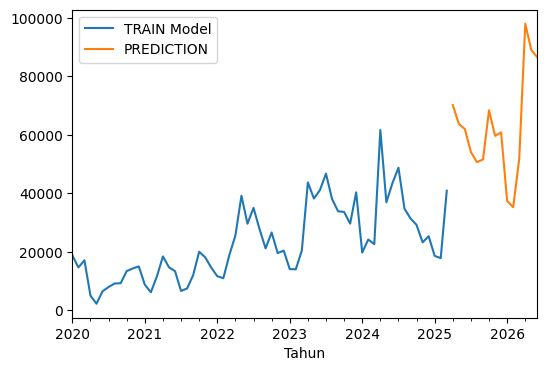

In [17]:
# Train model in full Dataset

# model HOLT WINTERS
fitted_model = HWES(sea_passanger['Penumpang'],trend='mul',seasonal='mul',seasonal_periods=12).fit()
full_predictions = fitted_model.forecast(15)
sea_passanger['Penumpang'].plot(legend=True,label= 'TRAIN Model')
full_predictions.plot(legend=True,label= 'PREDICTION', figsize=(6,4))
          

In [18]:
full_predictions


2025-04-01    70190.473798
2025-05-01    63745.094232
2025-06-01    61957.894962
2025-07-01    54109.264205
2025-08-01    50678.108917
2025-09-01    51570.627696
2025-10-01    68387.406007
2025-11-01    59644.353744
2025-12-01    60830.576227
2026-01-01    37409.322376
2026-02-01    35249.799770
2026-03-01    51776.406101
2026-04-01    97986.474493
2026-05-01    88988.671996
2026-06-01    86493.727223
Freq: MS, dtype: float64